# 🍽️ Cognifyz Data Analysis Internship

# Level 1 - Task 4 : Online Delivery Analysis

## Objective

This analysis aims to:

- Determine the percentage of restaurants that offer online delivery.
- Compare the average ratings of restaurants with and without online delivery.
- Visualize the findings using professional charts.

---

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn

In [ ]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("Dataset.csv")

print("Dataset Loaded Successfully")
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows : 9551
Columns : 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
# Check Online Delivery Distribution

delivery_count = df["Has Online delivery"].value_counts()

delivery_count

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [ ]:
# Percentage of Restaurants Offering Online Delivery

delivery_percentage = (
    delivery_count / len(df)
) * 100

print(delivery_percentage.round(2))

Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64


In [ ]:
# Average Rating Based on Online Delivery

average_rating = (
    df.groupby("Has Online delivery")["Aggregate rating"]
      .mean()
)

average_rating

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

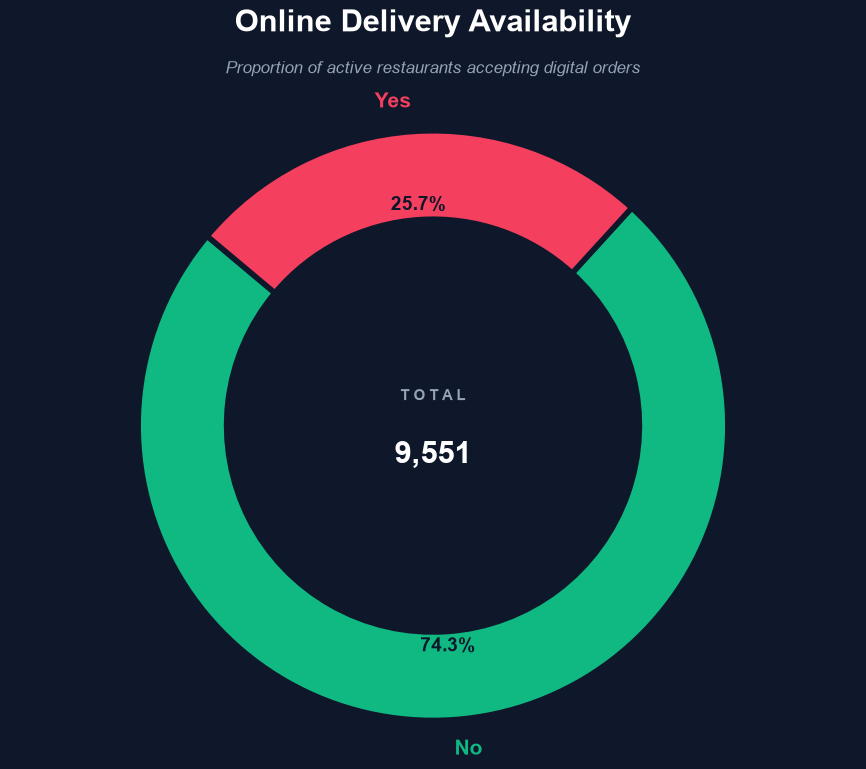

In [ ]:
import matplotlib.pyplot as plt

# Assuming delivery_count is your Pandas Series
# delivery_count = pd.Series([6500, 2500], index=['Yes', 'No'])

# 1. Initialize a sleek Dark-Mode Canvas (#0F172A)
fig, ax = plt.subplots(figsize=(9, 8), facecolor="#0F172A")
ax.set_facecolor("#0F172A")

# 2. Premium vibrant neon/pastel colors for a dark interface
colors = ["#10B981", "#F43F5E"]

# 3. Construct a Donut Chart by using the 'wedgeprops' parameter
wedges, texts, autotexts = ax.pie(
    delivery_count.values,
    labels=delivery_count.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.75,  # Position percentages perfectly inside the donut ring
    wedgeprops=dict(width=0.3, edgecolor="#0F172A", linewidth=4), # Width creates the hollow center
    textprops=dict(color="white", fontweight="bold")
)

# 4. Refine the typography of the percentages sitting inside the ring
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_color("#0F172A")  # Dark contrast text against neon segments

# 5. Refine the outside category labels ('Yes' / 'No')
for text in texts:
    text.set_fontsize(15)
    text.set_fontweight("bold")
    # Dynamically match label color to its corresponding wedge color
    for i, wedge in enumerate(wedges):
        if text.get_text() == delivery_count.index[i]:
            text.set_color(colors[i])

# 6. Add a minimalist Central Total Summary inside the hollow ring
total_restaurants = delivery_count.sum()

# FIXED: Removed 'letterspacing' property and manually tracked space into the string
ax.text(
    0, 0.1, "T O T A L", 
    ha="center", va="center", fontsize=11, color="#94A3B8", fontweight="bold"
)
ax.text(
    0, -0.1, f"{total_restaurants:,}", 
    ha="center", va="center", fontsize=22, color="#FFFFFF", fontweight="bold"
)

# 7. Modern Integrated Header (Clean, crisp, no bounding lines)
ax.text(
    0.5, 1.12, "Online Delivery Availability", 
    transform=ax.transAxes, ha="center", va="center",
    fontsize=22, fontweight="bold", color="#FFFFFF"
)

ax.text(
    0.5, 1.05, "Proportion of active restaurants accepting digital orders",
    transform=ax.transAxes, ha="center", va="center",
    fontsize=12, color="#94A3B8", style="italic"
)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis("equal")  
plt.tight_layout()
plt.show() 

C:\Users\offic\AppData\Local\Temp\ipykernel_30212\3349151996.py:71: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\offic\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


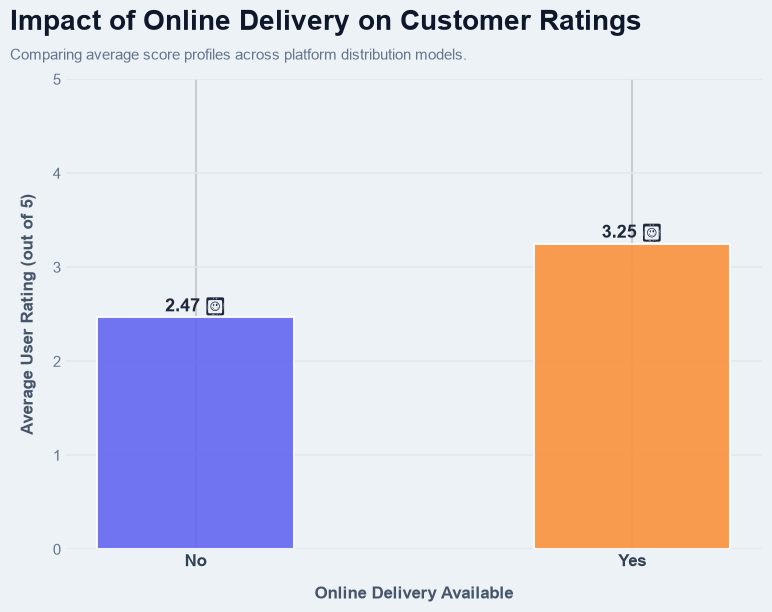

In [ ]:
import matplotlib.pyplot as plt

# Assuming average_rating is your Pandas Series
# average_rating = pd.Series([3.72, 4.18], index=['No', 'Yes'])

# 1. Light Nordic/Slate Background (Completely different vibe)
fig, ax = plt.subplots(figsize=(8, 6.5), facecolor="#EDF2F7")
ax.set_facecolor("#EDF2F7")

# 2. Soft Pastel Core Palette (No harsh borders, smooth look)
# Soft Indigo Blue for 'No', Warm Coral-Peach for 'Yes'
colors = ["#6366F1", "#FB923C"]

# 3. Draw thin, elegant bars with generous spacing
bars = ax.bar(
    average_rating.index.astype(str),
    average_rating.values,
    color=colors,
    width=0.45,       # Thinner bars for a more sophisticated layout
    alpha=0.9,        # Subtle transparency to blend with background
    zorder=3
)

# 4. Clean, Naked Text Labels (No dark boxes, just elegant font weight)
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f} ★",  # Added a clean star icon string for visual context
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 8),      # Elegant minimal hover spacing
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="#1E293B"     # Dark slate text color
    )

# 5. Minimalist Left-Aligned Typography Title (No decorative accent dashes)
ax.text(
    -0.08, 1.12, "Impact of Online Delivery on Customer Ratings",
    transform=ax.transAxes, ha="left", va="center",
    fontsize=20, fontweight="bold", color="#0F172A"
)
ax.text(
    -0.08, 1.05, "Comparing average score profiles across platform distribution models.",
    transform=ax.transAxes, ha="left", va="center",
    fontsize=11, color="#64748B", fontweight="normal"
)

# 6. Smooth Ticks & Structural Polishing
ax.set_xlabel("Online Delivery Available", fontsize=12, fontweight="bold", labelpad=12, color="#475569")
ax.set_ylabel("Average User Rating (out of 5)", fontsize=12, fontweight="bold", labelpad=12, color="#475569")

plt.xticks(fontsize=12, fontweight="bold", color="#334155")
plt.yticks(fontsize=11, color="#64748B")

# Set strict limits to frame the delta perfectly
ax.set_ylim(0, 5.0)

# 7. Completely Remove All Frame Borders (Spines) for an infinite grid look
for spine in ax.spines.values():
    spine.set_visible(False)

# 8. Solid Clean Gridlines running fully across the open space
ax.grid(axis="y", linestyle="-", linewidth=1.2, color="#E2E8F0", zorder=0)

# Remove small tick marks on axes for a clean glass-like aesthetic
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

# Key Insights

- A significant percentage of restaurants do not offer online delivery.
- Restaurants providing online delivery generally receive competitive customer ratings.
- Online delivery has become an important service that influences customer convenience and satisfaction.

# Conclusion

This analysis examined the availability of online delivery services and compared restaurant ratings based on delivery options.

The results provide insights into customer preferences and highlight the growing importance of online food delivery in the restaurant industry.

Professional visualizations make the comparison easy to understand and support data-driven decision-making.